# Multiclass Text Classification with Word2Vec model

In [ ]:
import pandas as pd #Data manipulation
import numpy as np
from scipy.stats import randint
import seaborn as sns # used for plot interactive graph.
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

from sklearn.feature_selection import chi2
from IPython.display import display
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from gensim.models import Word2Vec
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline


from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler




In [ ]:
new_header = ['id', 'Movie name', 'Genre', 'Movie description'] #assigning headers since txt file doesn't have header


df = pd.read_csv("sample_data/train_data.txt", header=None, names=new_header, sep=':::', engine='python')

### Exploration and Preprocessing

In [ ]:
df.head(2) #this way you can display columns as rows.

,id,Movie name,Genre,Movie description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...


Let's remove some information that we do not need and build another dataframe that contain Genre and movie description.

In [ ]:
# Create a new dataframe with two columns
df1 = df[['Genre', 'Movie description']].copy()

# Remove missing values (NaN)
df1 = df1[pd.notnull(df1['Movie description'])]

df1.shape

(54214, 2)

In [ ]:
# Percentage of movie description that had text field
total = df1['Movie description'].notnull().sum()
round((total/len(df)*100),1)

100.0

In [ ]:
pd.DataFrame(df1.Genre.unique()).values
#print(len(pd.DataFrame(df1.Genre.unique()).values))

array([[' drama '],
       [' thriller '],
       [' adult '],
       [' documentary '],
       [' comedy '],
       [' crime '],
       [' reality-tv '],
       [' horror '],
       [' sport '],
       [' animation '],
       [' action '],
       [' fantasy '],
       [' short '],
       [' sci-fi '],
       [' music '],
       [' adventure '],
       [' talk-show '],
       [' western '],
       [' family '],
       [' mystery '],
       [' history '],
       [' news '],
       [' biography '],
       [' romance '],
       [' game-show '],
       [' musical '],
       [' war ']], dtype=object)

There are 27 different classes or categories that we can use as out target variable.

In [ ]:
# let's work with a smaller smaple of the data to speed things up
df2 = df1.sample(10000, random_state=1).copy() #CBOW model
df3 = df1.sample(10000, random_state=2).copy() #Skip gram model
#df2 = df1.copy() #CBOW model
#df3 = df1.copy() #Skip gram model

In [ ]:
pd.DataFrame(df3.Genre.unique())
df3.Genre.value_counts()

,count
Genre,
drama,2474
documentary,2422
comedy,1358
short,918
horror,443
thriller,258
action,246
reality-tv,176
western,174


In [ ]:
pd.DataFrame(df2.Genre.unique())
df2.Genre.value_counts()

,count
Genre,
drama,2589
documentary,2378
comedy,1396
short,940
horror,397
thriller,276
action,239
western,184
family,158


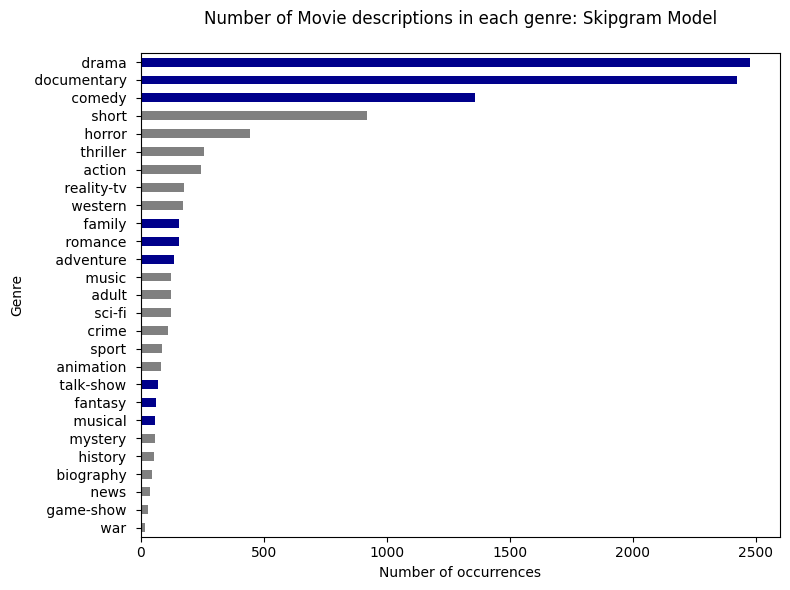

In [ ]:
fig = plt.figure(figsize=(8, 6))
colors = ['grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'darkblue', 'darkblue', 'darkblue']

df3.groupby('Genre')['Movie description'].count().sort_values().plot.barh(
    color=colors, title='Number of Movie descriptions in each genre: Skipgram Model\n'
)

plt.xlabel('Number of occurrences', fontsize=10)
plt.tight_layout()
plt.show()

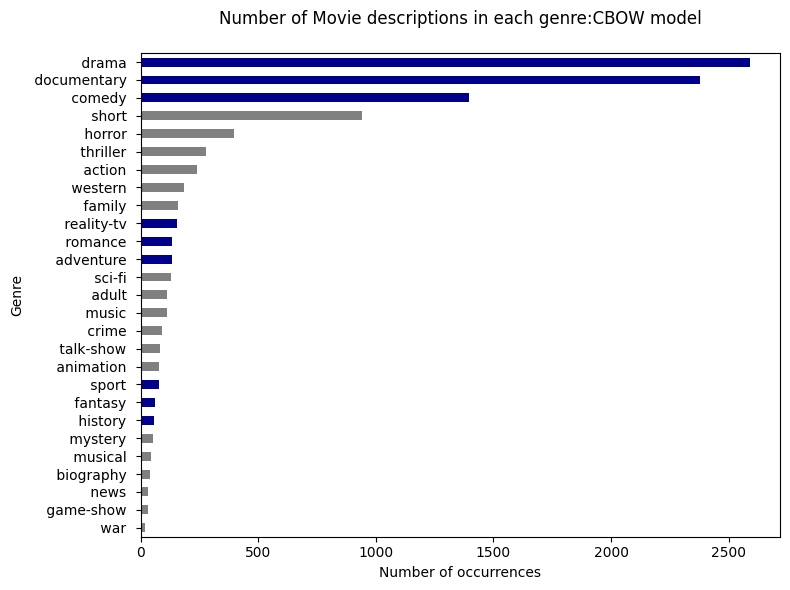

In [ ]:
fig = plt.figure(figsize=(8, 6))
colors = ['grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'darkblue', 'darkblue', 'darkblue']

df2.groupby('Genre')['Movie description'].count().sort_values().plot.barh(
    color=colors, title='Number of Movie descriptions in each genre:CBOW model\n'
)

plt.xlabel('Number of occurrences', fontsize=10)
plt.tight_layout()
plt.show()

Our dataset is highly unbalanced.
So undersampling in major datasets and oversampling in lower datasets to balance the datsets

In [ ]:
# Create a new column 'Tokenized_text' to tokenise the movie description
df3['Tokenized_Text'] = df3['Movie description'].apply(lambda x: x.lower().split())

df3.head(3)

,Genre,Movie description,Tokenized_Text
49672,drama,A bizarre couple and their seventeen-year-old...,"[a, bizarre, couple, and, their, seventeen-yea..."
48949,short,The world has been taken over by The Unknown....,"[the, world, has, been, taken, over, by, the, ..."
15204,drama,The drama tells the story about a variety of ...,"[the, drama, tells, the, story, about, a, vari..."


In [ ]:
# Create a new column 'Tokenized_Text' to tokenise the movie description
df2['Tokenized_Text'] = df2['Movie description'].apply(lambda x: x.lower().split())


# New dataframe
df2.head(2)

,Genre,Movie description,Tokenized_Text
10689,documentary,This documentary film is a heartfelt glimpse ...,"[this, documentary, film, is, a, heartfelt, gl..."
32392,short,"According to an old Chinese fairytale, the go...","[according, to, an, old, chinese, fairytale,, ..."


Let us now calculate Word2Vec scores.

CBOW model and SKip gram model

In [ ]:
# Training the Word2Vec model on tokenized text

# Using CBOW (default, sg=0)
model_cbow = Word2Vec(sentences= df2['Tokenized_Text'], vector_size=100, window=5, sg=0)

# Using Skip-Gram (sg=1)
model_skipgram = Word2Vec(sentences= df3['Tokenized_Text'], vector_size=100, window=5, sg=1)



In [ ]:
# Function to compute sentence vector by averaging word vectors
def compute_sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)  # Return a zero vector if no words are in the vocabulary

# Compute Word2Vec scores for each sentence
df2['Word2Vec_Score_cbow'] = df2['Tokenized_Text'].apply(lambda x: compute_sentence_vector(x, model_cbow))

df3['Word2Vec_Score_skipgram'] = df3['Tokenized_Text'].apply(lambda x: compute_sentence_vector(x, model_skipgram))

### Classification

Let us train several models, namely,

*   Random Forest
*   Linear Support Vector Machine
*   Logistic Regression

In [ ]:


#CBOW MODEL

# Features and labels
features = np.stack(df2['Word2Vec_Score_cbow'].values)  # Word2Vec sentence embeddings
labels = df2['Genre']  # Target labels (e.g., movie genres)

#label encoding
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
label_names = label_encoder.classes_


models = [
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0),
    LinearSVC(),
    LogisticRegression(random_state=0),
]

# 5 Cross-validation
CV = 5
cv_df = pd.DataFrame(index=range(CV * len(models)))

entries = []
for model in models:
  model_name = model.__class__.__name__
  accuracies = cross_val_score(model, features, labels_encoded, scoring='accuracy', cv=CV)
  for fold_idx, accuracy in enumerate(accuracies):
    entries.append((model_name, fold_idx, accuracy))

cv_df_cbow = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:

#skip gram MODEL

# Features and labels
features1 = np.stack(df3['Word2Vec_Score_skipgram'].values)  # Word2Vec sentence embeddings
labels1 = df3['Genre']  # Target labels (e.g., movie genres)

#label encoding
label_encoder = LabelEncoder()
labels_encoded1 = label_encoder.fit_transform(labels1)
label_names = label_encoder.classes_


models = [
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0),
    LinearSVC(),
    LogisticRegression(random_state=0),
]

# 5 Cross-validation
CV = 5
cv_df = pd.DataFrame(index=range(CV * len(models)))

entries = []
for model in models:
  model_name = model.__class__.__name__
  accuracies = cross_val_score(model, features1, labels_encoded1, scoring='accuracy', cv=CV)
  for fold_idx, accuracy in enumerate(accuracies):
    entries.append((model_name, fold_idx, accuracy))

cv_df_skipgram = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:

print("\n CBOW model\n")
mean_accuracy = cv_df_cbow.groupby('model_name').accuracy.mean()
std_accuracy = cv_df_cbow.groupby('model_name').accuracy.std()

acc_cbow = pd.concat([mean_accuracy, std_accuracy], axis= 1,
          ignore_index=True)
acc_cbow.columns = ['Mean Accuracy', 'Standard deviation']
acc_cbow






 CBOW model



,Mean Accuracy,Standard deviation
model_name,,
LinearSVC,0.4402,0.013850
LogisticRegression,0.4370,0.012614
RandomForestClassifier,0.4197,0.008779


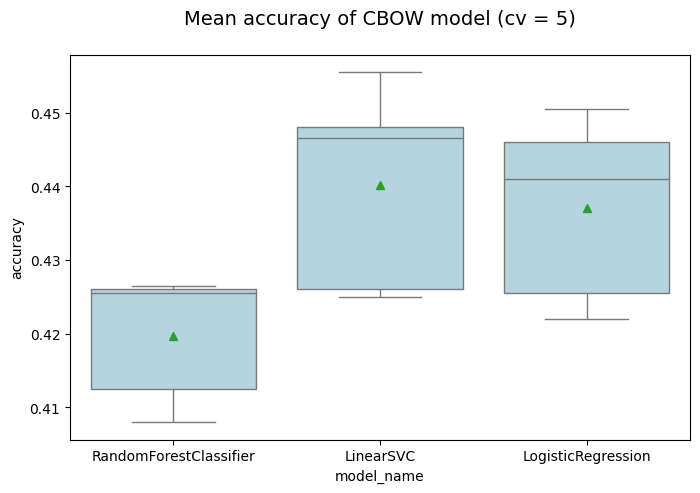

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='model_name', y='accuracy',
            data=cv_df_cbow,
            color='lightblue',
            showmeans=True)
plt.title("Mean accuracy of CBOW model (cv = 5)\n", size=14);

In [ ]:
print("\nSkip gram model\n")
mean_accuracy = cv_df_skipgram.groupby('model_name').accuracy.mean()
std_accuracy = cv_df_skipgram.groupby('model_name').accuracy.std()

acc_skipgram = pd.concat([mean_accuracy, std_accuracy], axis= 1,
          ignore_index=True)
acc_skipgram.columns = ['Mean Accuracy', 'Standard deviation']
acc_skipgram


Skip gram model



,Mean Accuracy,Standard deviation
model_name,,
LinearSVC,0.4708,0.003365
LogisticRegression,0.4615,0.002031
RandomForestClassifier,0.4241,0.004129


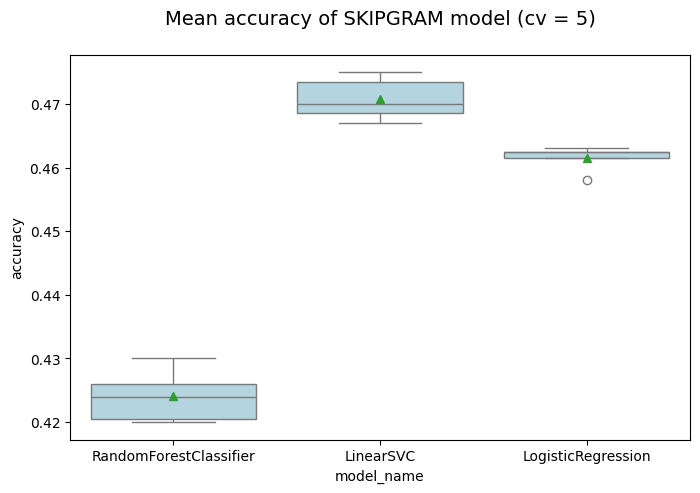

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='model_name', y='accuracy',
            data=cv_df_skipgram,
            color='lightblue',
            showmeans=True)
plt.title("Mean accuracy of SKIPGRAM model (cv = 5)\n", size=14);

Evaluation
So going with the Linear SVC, since it is better!

In [ ]:
#CBOW model


x_train, x_test, y_train, y_test = train_test_split(features, labels_encoded,
                                                    test_size=0.25,
                                                    random_state = 0)


model = LinearSVC(random_state=0, max_iter=10000)  # Increased max_iter to ensure convergence
model.fit(x_train, y_train)

y_pred = model.predict(x_test)




#Skip gram model


X_train_skipgram, X_test_skipgram, y_train_skipgram, y_test_skipgram = train_test_split(features1,
                                                               labels_encoded1,
                                                               test_size=0.25,
                                                               random_state=0)
model = LinearSVC()
model.fit(X_train_skipgram, y_train_skipgram)
y_pred_skipgram = model.predict(X_test_skipgram)



In [ ]:
# Classification report

#CBOW
print('\t\t\t\tCLASSIFICATION METRICS: CBOW\n')
print(metrics.classification_report(y_test, y_pred, target_names=label_names))




accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")





				CLASSIFICATION METRICS: CBOW

               precision    recall  f1-score   support

      action        0.00      0.00      0.00        70
       adult        0.00      0.00      0.00        34
   adventure        0.00      0.00      0.00        42
   animation        0.00      0.00      0.00        15
   biography        0.00      0.00      0.00        11
      comedy        0.36      0.34      0.35       347
       crime        0.00      0.00      0.00        39
 documentary        0.54      0.89      0.68       612
       drama        0.43      0.75      0.55       605
      family        0.00      0.00      0.00        31
     fantasy        0.00      0.00      0.00        14
   game-show        0.00      0.00      0.00         5
     history        0.00      0.00      0.00        14
      horror        0.25      0.11      0.15        92
       music        0.44      0.11      0.17        38
     musical        0.00      0.00      0.00        15
     mystery        0.00      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

#skipgram
print('\t\t\t\tCLASSIFICATIION METRICS : SKipgram\n')
print(metrics.classification_report(y_test_skipgram, y_pred_skipgram,
                                    target_names= df3['Genre'].unique()))

				CLASSIFICATIION METRICS : SKipgram

               precision    recall  f1-score   support

       drama        0.00      0.00      0.00        70
       short        0.00      0.00      0.00        34
      comedy        0.00      0.00      0.00        42
      horror        0.00      0.00      0.00        15
 documentary        0.00      0.00      0.00        11
  reality-tv        0.36      0.34      0.35       347
    thriller        0.00      0.00      0.00        39
     romance        0.54      0.89      0.68       612
      sci-fi        0.43      0.75      0.55       605
   animation        0.00      0.00      0.00        31
       adult        0.00      0.00      0.00        14
     musical        0.00      0.00      0.00         5
   biography        0.00      0.00      0.00        14
      family        0.25      0.11      0.15        92
        news        0.44      0.11      0.17        38
     fantasy        0.00      0.00      0.00        15
       sport        0.00

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


test on unseen data

In [ ]:
review = ''